In [4]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

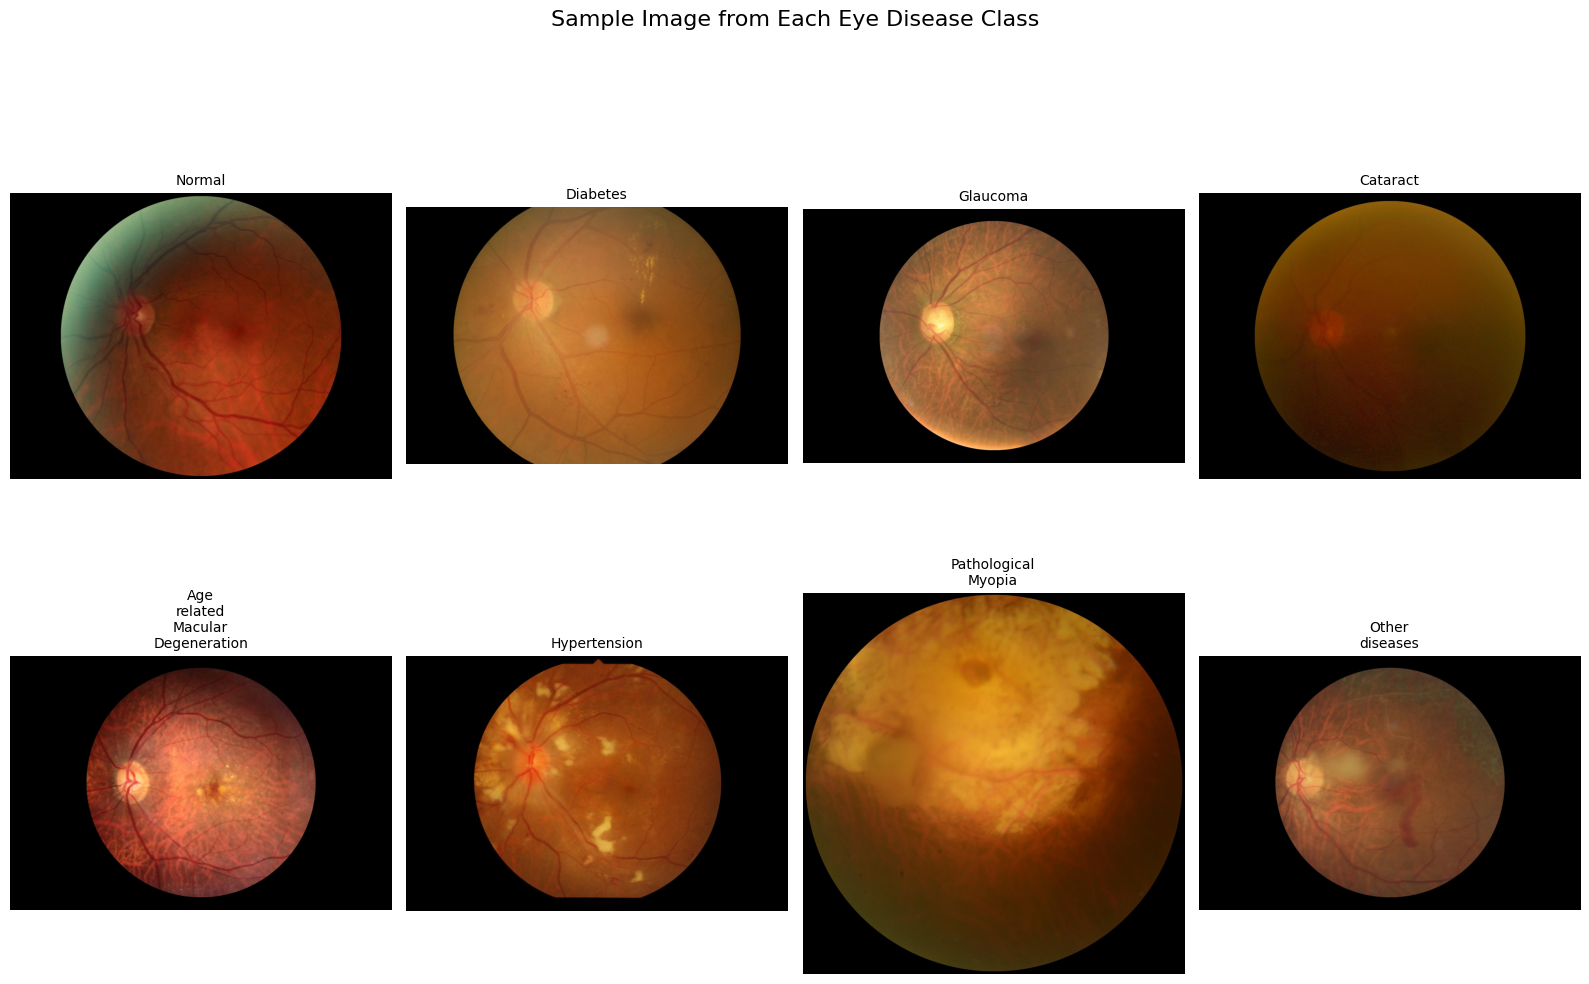

In [2]:
# Display some images from each class in the multi-label classification dataset
# Root directory path
root_path = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/multi_label_classification'

# List of classes (as provided)
disease_classes = [
    'Normal',
    'Diabetes',
    'Glaucoma',
    'Cataract',
    'Age_related_Macular_Degeneration',
    'Hypertension',
    'Pathological_Myopia',
    'Other_diseases'
]

# Create a figure to plot all class samples
plt.figure(figsize=(16, 10))

for i, disease in enumerate(disease_classes):
    class_path = os.path.join(root_path, disease)

    # Check both left_eye and right_eye folders
    left_eye_path = os.path.join(class_path, 'left_eye')
    right_eye_path = os.path.join(class_path, 'right_eye')

    # Collect all valid image files (exclude files starting with ._)
    left_images = [f for f in os.listdir(left_eye_path) if f.lower().endswith(('.jpg', '.png', '.jpeg')) and not f.startswith('._')]
    right_images = [f for f in os.listdir(right_eye_path) if f.lower().endswith(('.jpg', '.png', '.jpeg')) and not f.startswith('._')]

    # Pick one image randomly from left_eye or right_eye
    chosen_folder = left_eye_path if left_images else right_eye_path
    chosen_images = left_images if left_images else right_images

    if not chosen_images:
        print(f"No valid images found for class: {disease}")
        continue

    sample_image_path = os.path.join(chosen_folder, random.choice(chosen_images))

    # Load and plot the image
    image = Image.open(sample_image_path).convert("RGB")
    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(disease.replace('_', '\n'), fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Sample Image from Each Eye Disease Class", fontsize=16, y=1.05)
plt.show()


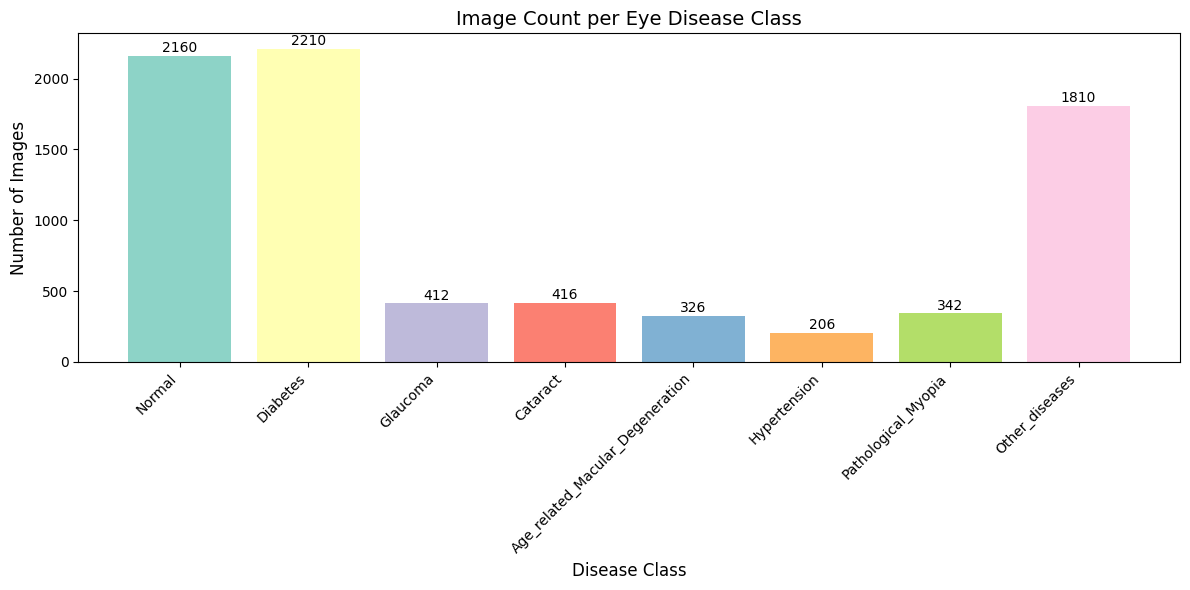

In [5]:
# Count of the image in each class

# Root directory
root_path = '/Volumes/KODAK/folder_02/eye_disease_prediction_model/data/preprocess_data/multi_label_classification'

# Initialize dictionary to hold image counts
class_counts = {}

# Loop through each disease class folder
for class_name in os.listdir(root_path):
    class_path = os.path.join(root_path, class_name)

    if not os.path.isdir(class_path):
        continue

    left_eye_path = os.path.join(class_path, 'left_eye')
    right_eye_path = os.path.join(class_path, 'right_eye')

    left_images = [f for f in os.listdir(left_eye_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')] if os.path.exists(left_eye_path) else []
    right_images = [f for f in os.listdir(right_eye_path) if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._')] if os.path.exists(right_eye_path) else []

    total_count = len(left_images) + len(right_images)
    class_counts[class_name] = total_count

# Prepare data
classes = list(class_counts.keys())
counts = list(class_counts.values())

# Create colormap
cmap = plt.get_cmap('Set3')  # Try 'tab10', 'Set2', 'viridis', etc.
colors = [cmap(i) for i in range(len(classes))]

# Plotting
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, counts, color=colors)
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Image Count per Eye Disease Class', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
